# 04 Train and Evaluate with W&B

Run the full train-to-evaluation pipeline and log experiment results to Weights & Biases. This notebook logs config values, data sizes, train/validation losses, BLEU, chrF, sample translations, and checkpoint artifacts.

## Colab Setup

Run the next cell first when using Google Colab. It clones the repository, installs project dependencies from `pyproject.toml`, and moves the working directory to the repository root.

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/songhahyun/seq2seq_transformer_model.git"
REPO_DIR = Path("/content/seq2seq_transformer_model")

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "--branch", "dev", "--single-branch", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", ".[notebooks]"], check=True)
else:
    print("Not running in Colab; skipping clone/install.")

print(f"cwd: {Path.cwd()}")

cwd: /content/seq2seq_transformer_model


In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"repo root: {REPO_ROOT}")

repo root: /content/seq2seq_transformer_model


## W&B settings

Set `WANDB_MODE = "offline"` if you want to log locally without syncing immediately. For online logging, put `WANDB_API_KEY` in `.env` or run `wandb login` before executing this notebook.

In [ ]:
from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env", override=False)

PROJECT_NAME = os.getenv("WANDB_PROJECT", "seq2seq-transformer")
ENTITY_NAME = os.getenv("WANDB_ENTITY") or None
RUN_NAME = "experiment_03"
WANDB_MODE = os.getenv("WANDB_MODE", "online")  # "online" or "offline"
WANDB_API_KEY = os.getenv("WANDB_API_KEY", "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")
LOG_ARTIFACTS = True
NUM_SAMPLE_TRANSLATIONS = 10
WATCH_LOG = None  # None, "gradients", "parameters", or "all"
WATCH_LOG_FREQ = 100

os.environ["WANDB_MODE"] = WANDB_MODE

# if WANDB_MODE == "online" and not os.getenv("WANDB_API_KEY"):
#     raise RuntimeError("WANDB_API_KEY is missing. Add it to .env, run wandb login, or set WANDB_MODE='offline'.")

print(f"W&B mode: {WANDB_MODE}")
print(f"W&B project: {PROJECT_NAME}")
print(f"W&B entity: {ENTITY_NAME or '(default)'}")
# print(f"W&B API key loaded: {bool(os.getenv('WANDB_API_KEY'))}")

W&B mode: online
W&B project: seq2seq-transformer
W&B entity: (default)


In [ ]:
import torch.optim as optim
import wandb

from src.config import Config
from src.data_pipeline import (
    create_dataloaders,
    extract_pairs,
    load_ko_en_dataset,
    maybe_take_subset,
    prepare_tokenizers,
    set_seed,
    split_pairs,
)
from src.evaluate import generate_predictions, print_sample_translations
from src.metrics import compute_bleu, compute_chrf
from src.model_utils import build_model
from src.train import create_loss_fn, save_checkpoint, train_one_epoch, validate_one_epoch
from src.wandb_experiment import config_for_wandb, log_checkpoint_artifacts

config = Config()
set_seed(config.random_seed)

print(f"device: {config.device}")
print(f"dataset: {config.dataset_name}")

device: cuda
dataset: shihyunlim/aihub-ko-en-everyday-expression


## Initialize W&B run

In [ ]:
# if WANDB_MODE == "online":
#     wandb.login(key=os.getenv("WANDB_API_KEY"), relogin=False, timeout=60)

if WANDB_MODE == "online":
    wandb.login(key=WANDB_API_KEY, relogin=False, timeout=60)

run = wandb.init(
    project=PROJECT_NAME,
    entity=ENTITY_NAME,
    name=RUN_NAME,
    config=config_for_wandb(config),
    settings=wandb.Settings(init_timeout=120),
)

run.name

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hahyunsong491 (hahyunsong491-sogang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


'experiment_03'

## Load and split dataset

In [ ]:
dataset = load_ko_en_dataset(
    config.dataset_name,
    split=config.train_split,
    hf_token=config.hf_token,
)
pairs = extract_pairs(dataset, src_col="ko", tgt_col="en")

train_pairs, valid_pairs, test_pairs = split_pairs(
    pairs,
    valid_ratio=config.valid_ratio,
    test_ratio=config.test_ratio,
    seed=config.random_seed,
)

train_pairs = maybe_take_subset(train_pairs, config.train_subset_size)
valid_pairs = maybe_take_subset(valid_pairs, config.valid_subset_size)
test_pairs = maybe_take_subset(test_pairs, config.test_subset_size)

wandb.log({
    "data/total_pairs": len(pairs),
    "data/train_pairs": len(train_pairs),
    "data/valid_pairs": len(valid_pairs),
    "data/test_pairs": len(test_pairs),
})

print(f"total pairs: {len(pairs)}")
print(f"train pairs: {len(train_pairs)}")
print(f"valid pairs: {len(valid_pairs)}")
print(f"test pairs : {len(test_pairs)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/134M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1690052 [00:00<?, ? examples/s]

total pairs: 1690052
train pairs: 200000
valid pairs: 2000
test pairs : 2000


## Prepare tokenizers and dataloaders

In [ ]:
sp_src, sp_tgt = prepare_tokenizers(train_pairs, config)

train_loader, valid_loader, test_loader = create_dataloaders(
    train_pairs,
    valid_pairs,
    test_pairs,
    sp_src,
    sp_tgt,
    config,
)

wandb.config.update(
    {
        "src_actual_vocab_size": sp_src.get_piece_size(),
        "tgt_actual_vocab_size": sp_tgt.get_piece_size(),
        "train_batches": len(train_loader),
        "valid_batches": len(valid_loader),
        "test_batches": len(test_loader),
    },
    allow_val_change=True,
)

print(f"src vocab size: {sp_src.get_piece_size()}")
print(f"tgt vocab size: {sp_tgt.get_piece_size()}")

src vocab size: 8000
tgt vocab size: 8000


## Build model

In [ ]:
model = build_model(
    config=config,
    src_vocab_size=sp_src.get_piece_size(),
    tgt_vocab_size=sp_tgt.get_piece_size(),
)
optimizer = optim.Adam(model.parameters(), lr=config.lr)
criterion = create_loss_fn(config.pad_id)

num_parameters = sum(p.numel() for p in model.parameters())
wandb.config.update({"num_parameters": num_parameters}, allow_val_change=True)

if WATCH_LOG is not None:
    wandb.watch(model, log=WATCH_LOG, log_freq=WATCH_LOG_FREQ)

print(f"parameters: {num_parameters:,}")

parameters: 3,743,040


## Train and log losses

In [ ]:
history = []
best_valid_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(config.num_epochs):
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        config.device,
    )
    valid_loss = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        config.device,
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
    })

    wandb.log(
        {
            "epoch": epoch + 1,
            "train/loss": train_loss,
            "valid/loss": valid_loss,
        },
        step=epoch + 1,
    )

    print(
        f"[Epoch {epoch + 1}/{config.num_epochs}] "
        f"train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f}"
    )

    latest_checkpoint_path = f"{config.checkpoint_dir}/latest.pt"
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        config=config,
        epoch=epoch + 1,
        train_loss=train_loss,
        valid_loss=valid_loss,
        src_vocab_size=sp_src.get_piece_size(),
        tgt_vocab_size=sp_tgt.get_piece_size(),
        path=latest_checkpoint_path,
    )

    improved = valid_loss < best_valid_loss - config.early_stopping_min_delta
    if improved:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0
        best_checkpoint_path = f"{config.checkpoint_dir}/best.pt"
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            config=config,
            epoch=epoch + 1,
            train_loss=train_loss,
            valid_loss=valid_loss,
            src_vocab_size=sp_src.get_piece_size(),
            tgt_vocab_size=sp_tgt.get_piece_size(),
            path=best_checkpoint_path,
        )
        wandb.run.summary["best_valid_loss"] = best_valid_loss
        wandb.run.summary["best_epoch"] = epoch + 1
        print(f"saved best checkpoint: {best_checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(
            "no validation improvement "
            f"({epochs_without_improvement}/{config.early_stopping_patience})"
        )
        wandb.log(
            {
                "early_stopping/epochs_without_improvement": epochs_without_improvement,
            },
            step=epoch + 1,
        )

        if epochs_without_improvement >= config.early_stopping_patience:
            print(
                "early stopping triggered: "
                f"best_valid_loss={best_valid_loss:.4f}"
            )
            wandb.run.summary["early_stopped"] = True
            wandb.run.summary["stopped_epoch"] = epoch + 1
            break
else:
    wandb.run.summary["early_stopped"] = False

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[Epoch 1/16] train_loss=5.2313 | valid_loss=4.6638
saved best checkpoint: checkpoints/best.pt
[Epoch 2/16] train_loss=4.5844 | valid_loss=4.3449
saved best checkpoint: checkpoints/best.pt
[Epoch 3/16] train_loss=4.3379 | valid_loss=4.1180
saved best checkpoint: checkpoints/best.pt
[Epoch 4/16] train_loss=4.1536 | valid_loss=3.9408
saved best checkpoint: checkpoints/best.pt
[Epoch 5/16] train_loss=4.0058 | valid_loss=3.8108
saved best checkpoint: checkpoints/best.pt
[Epoch 6/16] train_loss=3.8861 | valid_loss=3.6997
saved best checkpoint: checkpoints/best.pt
[Epoch 7/16] train_loss=3.7838 | valid_loss=3.6055
saved best checkpoint: checkpoints/best.pt
[Epoch 8/16] train_loss=3.6951 | valid_loss=3.5236
saved best checkpoint: checkpoints/best.pt
[Epoch 9/16] train_loss=3.6161 | valid_loss=3.4545
saved best checkpoint: checkpoints/best.pt
[Epoch 10/16] train_loss=3.5470 | valid_loss=3.3915
saved best checkpoint: checkpoints/best.pt
[Epoch 11/16] train_loss=3.4845 | valid_loss=3.3356
saved b

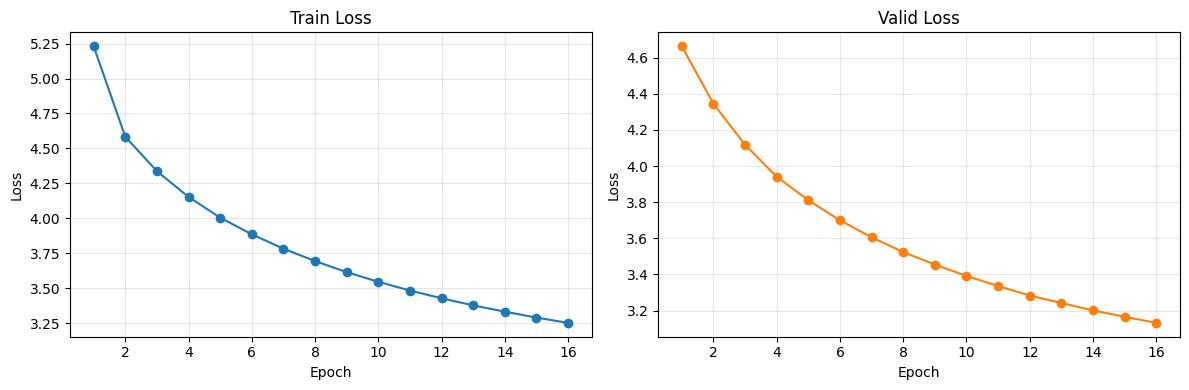

In [ ]:
import matplotlib.pyplot as plt

epochs = [item["epoch"] for item in history]
train_losses = [item["train_loss"] for item in history]
valid_losses = [item["valid_loss"] for item in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(epochs, train_losses, marker="o", color="tab:blue")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, valid_losses, marker="o", color="tab:orange")
axes[1].set_title("Valid Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate and log metrics

In [ ]:
source_texts, predictions, references = generate_predictions(
    model=model,
    dataloader=test_loader,
    sp_tgt=sp_tgt,
    config=config,
    device=config.device,
)

bleu = compute_bleu(predictions, references)
chrf = compute_chrf(predictions, references)

wandb.log({
    "test/bleu": bleu,
    "test/chrf": chrf,
})
wandb.run.summary["test_bleu"] = bleu
wandb.run.summary["test_chrf"] = chrf

print(f"BLEU: {bleu:.4f}")
print(f"chrF: {chrf:.4f}")

BLEU: 7.5670
chrF: 26.5584


## Log sample translations

In [ ]:
sample_count = min(NUM_SAMPLE_TRANSLATIONS, len(predictions))
sample_table = wandb.Table(columns=["source", "reference", "prediction"])

for i in range(sample_count):
    sample_table.add_data(source_texts[i], references[i], predictions[i])

wandb.log({"samples/translations": sample_table})

print_sample_translations(
    source_texts=source_texts,
    predictions=predictions,
    references=references,
    n=sample_count,
)


[Sample Translations: 10]

[1]
SRC : 새틴 베개는 킹 사이즈와 퀸 사이즈가 있습니다.
REF : The satin pillow comes in king size, and queen size.
PRED: The size of the size is a size and size.

[2]
SRC : 죄송하지만, 귀하의 멤버들이 우리를 공격하고 있어요.
REF : Sorry, but your members are attacking us.
PRED: Sorry, I'm sorry, but we are looking forward to our research.

[3]
SRC : 저는 마음껏 먹는 편입니다.
REF : I am a hearty eater.
PRED: I like a diet.

[4]
SRC : 프로토타입을 보내 주신 것도 감사합니다.
REF : Thank you for also sending the prototypes.
PRED: Thank you for sending a proposal.

[5]
SRC : 지금은 그것뿐입니다, 기다려 주셔서 감사합니다.
REF : That is all for now, and thank you for your patience.
PRED: That's right now, and thank you for your patience.

[6]
SRC : 고객님께서 문의하신 내용이 발송되었습니다.
REF : Your question has been sent.
PRED: I've sent you the invoice of the invoice.

[7]
SRC : 좋아, 공포 영화를 보자.
REF : OK, we can watch a horror film.
PRED: OK, I like watching movies.

[8]
SRC : 기분이 좋지 않습니다.
REF : I'm not feeling so good.
PRED: I don't feel like it.

[9]
SRC : 건드리고 싶은 마

## Log checkpoint artifacts and finish

In [ ]:
if LOG_ARTIFACTS:
    log_checkpoint_artifacts(wandb, config, run.name)

run.finish()

data/test_pairs,▁
data/total_pairs,▁
data/train_pairs,▁
data/valid_pairs,▁
epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
test/bleu,▁
test/chrf,▁
train/loss,█▆▅▄▄▃▃▃▂▂▂▂▁▁▁▁
valid/loss,█▇▆▅▄▄▃▃▂▂▂▂▂▁▁▁
best_epoch,16
best_valid_loss,3.13155
